# Computação de Alto Desempenho: Projeto Final (CIFAR-10)

Este notebook é o **entregável final** do projeto e serve como roteiro de apresentação. Ele percorre a mesma jornada que o projeto seguiu:

1. **O problema** que motivou o trabalho;
2. **A base de dados** utilizada;
3. **A implementação baseline**, sequencial e sem otimizações;
4. **O profiling da baseline**, indicando onde estão os gargalos e qual otimização deve atacar cada um;
5. **As otimizações**, apresentadas em ordem de complexidade de implementação exigida: Vetorização (NumPy), Numba, Multiprocessing e, por fim, GPU;
6. **A análise de performance**, com 5.000 imagens e com escalonamento do volume de dados;
7. **A conclusão**, com o profiling da melhor versão e a justificativa de por que ela venceu as demais.

> **Nota sobre reprodutibilidade:** as células de código abaixo usam o código real do repositório (`common/`, `experiments/`, `benchmark/`). Os números de tempo apresentados como referência principal foram medidos pelas autoras, com a base **CIFAR-10**, e estão salvos em `outputs/benchmarks/` e `outputs/profiling/`. Para seguir o mesmo fluxo, é necessário baixar a base de dados localmente na máquina de execução.

In [1]:
# Setup: garante que a raiz do projeto está no path e confere se a base CIFAR-10 está disponível

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "common").exists():
    for parent in Path.cwd().parents:
        if (parent / "common").exists():
            PROJECT_ROOT = parent
            break

sys.path.insert(0, str(PROJECT_ROOT))

from common.config import CIFAR10_DIR

DATASET_AVAILABLE = CIFAR10_DIR.exists() and any(CIFAR10_DIR.glob("data_batch_*"))

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Base CIFAR-10 encontrada em {CIFAR10_DIR}: {DATASET_AVAILABLE}")

if not DATASET_AVAILABLE:
    print(
        "\nAVISO: a base CIFAR-10 não foi encontrada em data/cifar-10-batches-py.\n"
        "Baixe em https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz, extraia na pasta\n"
        "'data/' na raiz do projeto, e rode esta célula novamente.\n"
        "As células abaixo que dependem de execução ao vivo vão avisar caso a base não esteja presente;\n"
        "os números de referência (tabelas e gráficos principais) já estão salvos em outputs/ e não dependem disso."
    )

Raiz do projeto: /home/malusevilha/7-semestre/CompDes/projeto-final-compdes
Base CIFAR-10 encontrada em /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/data/cifar-10-batches-py: True


## 1. Apresentação do problema

Processamento de imagens costuma parecer barato quando pensamos em uma única imagem, mas deixa de ser trivial quando a mesma sequência de operações precisa ser repetida milhares (ou milhões) de vezes. É exatamente esse o cenário de qualquer pipeline real de visão computacional: uma etapa de pré-processamento é aplicada a **todo** o dataset antes de qualquer modelo ver os dados.

**O problema escolhido para este projeto foi:**

> Construir e otimizar um pipeline de processamento de imagens da CIFAR-10, aplicando conversão para escala de cinza e detecção de bordas (operador de Sobel) em todas as imagens selecionadas.

Esse problema é um bom estudo de caso de Computação de Alto Desempenho porque:

- É uma tarefa **massivamente paralela por natureza**: cada imagem é processada de forma independente das demais;
- Tem uma implementação sequencial trivial de escrever (loops `for`), mas com desempenho ruim;
- Admite múltiplas estratégias de otimização com trade-offs diferentes: vetorização, compilação JIT, paralelismo entre processos e paralelismo massivo em GPU;
- O resultado (corretude do processamento) é fácil de validar entre as versões, já que todas devem produzir a mesma imagem em escala de cinza e os mesmos mapas de borda.

O pipeline completo implementado é:

```
Carregar batches da CIFAR-10 (pickle)
        ↓
Reconstruir imagens RGB (3072 - 32x32x3)
        ↓
Converter para escala de cinza (0.299 R + 0.587 G + 0.114 B)
        ↓
Aplicar detector de bordas (Sobel)
        ↓
Imagens processadas, prontas para uma etapa seguinte
```

As etapas de **conversão para cinza** e **detecção de bordas** são o alvo principal de otimização deste projeto, pois são elas que escalam com o número de imagens e com o número de pixels por imagem.

## 2. Apresentação da base de dados

A base utilizada é a **CIFAR-10**, um conjunto clássico de imagens coloridas amplamente usado em introdução à visão computacional.

**Características principais:**

| Propriedade | Valor |
|---|---|
| Total de imagens | 60.000 |
| Resolução | 32 x 32 pixels, 3 canais (RGB) |
| Classes | 10 (mutuamente exclusivas) |
| Imagens de treino | 50.000 (5 arquivos `data_batch_1..5`) |
| Imagens de teste | 10.000 (`test_batch`) |

Classes: `airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`.

**Formato bruto dos dados:** cada arquivo de batch é um dicionário pickle com:
- `data`: matriz `10000 × 3072` (`uint8`). Aqui, cada linha é uma imagem "achatada": 1024 valores do canal vermelho (R), seguidos de 1024 do canal verde (G), seguidos de 1024 do canal azul (B);
- `labels`: lista de 10000 rótulos inteiros.

Isso significa que **antes de qualquer processamento** já existe uma etapa de reconstrução: transformar o vetor de 3072 posições de volta em uma imagem `32x32x3`. Essa reconstrução (`reshape` + `transpose`) tem custo praticamente desprezível frente às demais etapas, como o profiling vai confirmar, mas ela é necessária e faz parte do pipeline.

Para todas as comparações de performance deste notebook, foi usado um subconjunto de **5.000 imagens de treino**, tamanho suficiente para expor gargalos de forma clara sem tornar o baseline inviável de rodar.

Shape flat (como vem do pickle): (5000, 3072), dtype=uint8
Shape reconstruído (RGB):        (5000, 32, 32, 3)
Classes disponíveis: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Distribuição de classes na amostra de 5.000 imagens:
  airplane     505
  automobile   460
  bird         519
  cat          486
  deer         519
  dog          488
  frog         519
  horse        486
  ship         520
  truck        498


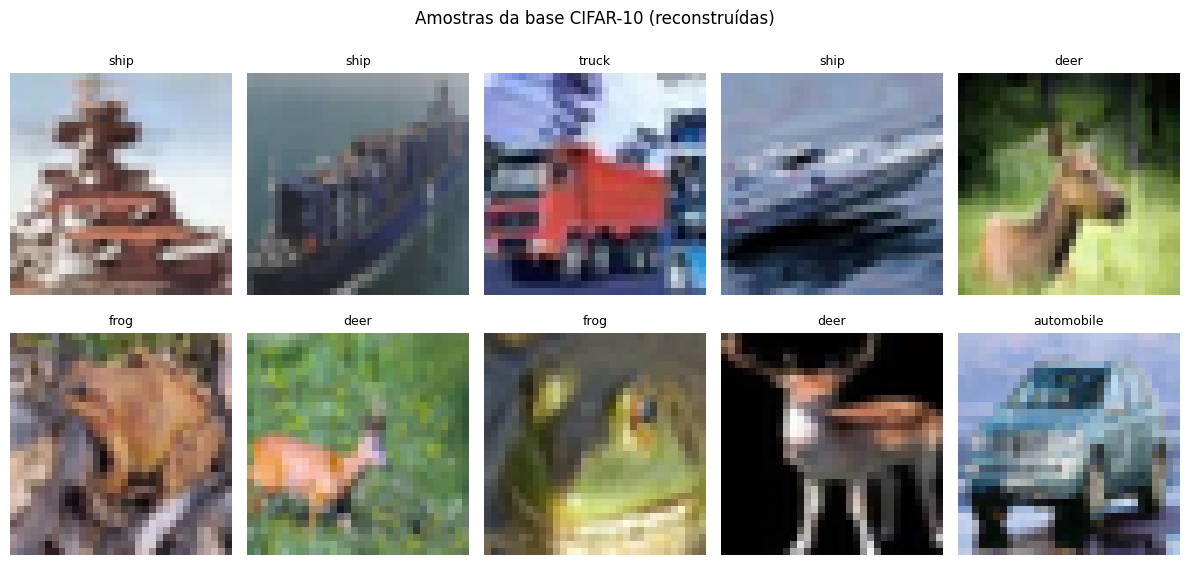

In [2]:
# Inspeção da base
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from common.dataset import load_dataset, reconstruct_images

if DATASET_AVAILABLE:
    images_flat, labels, class_names = load_dataset(CIFAR10_DIR, dataset="cifar10", split="train", limit=5000)
    images_rgb = reconstruct_images(images_flat)

    print(f"Shape flat (como vem do pickle): {images_flat.shape}, dtype={images_flat.dtype}")
    print(f"Shape reconstruído (RGB):        {images_rgb.shape}")
    print(f"Classes disponíveis: {class_names}")

    counts = Counter(labels.tolist())
    print("\nDistribuição de classes na amostra de 5.000 imagens:")
    for c in sorted(counts):
        name = class_names[c] if class_names else str(c)
        print(f"  {name:<12} {counts[c]}")

    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(images_rgb), size=10, replace=False)
    for ax, idx in zip(axes.flat, sample_idx):
        ax.imshow(images_rgb[idx].astype(np.uint8))
        label = int(labels[idx])
        title = class_names[label] if class_names else str(label)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    fig.suptitle("Amostras da base CIFAR-10 (reconstruídas)")
    fig.tight_layout()
    plt.show()
else:
    print("Base CIFAR-10 não encontrada — pulei a inspeção ao vivo. Veja outputs/verification/sample_0.png para um exemplo já gerado.")

## 3. Estrutura baseline

A primeira versão do pipeline (`experiments/baseline/`) foi escrita em **Python puro**, sem nenhuma otimização: apenas laços `for` explícitos.

Ela cumpre dois papéis:
1. **Referência de corretude**: todas as outras versões são validadas contra a saída dela;
2. **Linha de base de desempenho**: sendo uma implementação ingênua, ela serve de ponto de partida para medir qualquer ganho.

### Conversão para escala de cinza (baseline)

```python
def rgb_to_grayscale_single(image_rgb: np.ndarray) -> np.ndarray:
    gray = np.empty((32, 32), dtype=np.float32)
    for i in range(32):
        for j in range(32):
            r = float(image_rgb[i, j, 0])
            g = float(image_rgb[i, j, 1])
            b = float(image_rgb[i, j, 2])
            gray[i, j] = 0.299 * r + 0.587 * g + 0.114 * b
    return gray
```

Cada pixel é visitado individualmente, em Python interpretado (1.024 iterações por imagem só nesta etapa).

### Detecção de bordas (Sobel, baseline)

A implementação percorre cada pixel e, para cada um, percorre também sua vizinhança 3×3 (`di`, `dj` de -1 a 1), aplicando manualmente os pesos do kernel de Sobel horizontal e vertical, com *clamping* manual nas bordas da imagem:

```python
def sobel_single(gray_image: np.ndarray) -> np.ndarray:
    edges = np.empty((32, 32), dtype=np.float32)
    for i in range(32):
        for j in range(32):
            gx = gy = 0.0
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    ii = _clamp(i + di, 0, 31)
                    jj = _clamp(j + dj, 0, 31)
                    val = float(gray_image[ii, jj])
                    # ... acumula gx e gy conforme o kernel de Sobel
            edges[i, j] = (gx * gx + gy * gy) ** 0.5
    # normalização pelo valor máximo
    ...
```

Isso dá **32 x 32 x 9 = 9.216 iterações do laço mais interno por imagem**, só para o Sobel. Para 5.000 imagens, são mais de **46 milhões de iterações** nesse laço, cada uma com chamadas de função Python (`_clamp`) e aritmética escalar. Esse volume de trabalho repetitivo, em Python interpretado, é exatamente o tipo de padrão que o profiling da próxima seção vai expor como gargalo.

O pipeline completo (`process_pipeline`) mede o tempo de cada etapa separadamente: carregamento dos dados, reconstrução RGB e pré-processamento (grayscale + Sobel juntos, nesta versão).

In [3]:
# Executa o pipeline baseline e mostra o tempo de cada etapa
from experiments.baseline.pipeline import process_pipeline as run_baseline

if DATASET_AVAILABLE:
    baseline_result = run_baseline(dataset="cifar10", split="train", limit=5000)
    t = baseline_result.timings
    n = baseline_result.images_rgb.shape[0]

    print("=== Baseline — 5.000 imagens ===")
    print(f"Load data:       {t.load_data_s:.4f} s")
    print(f"Reconstruct RGB: {t.reconstruct_rgb_s:.6f} s")
    print(f"Preprocess:      {t.preprocess_s:.4f} s  (grayscale + Sobel, medidos juntos nesta versão)")
    print(f"Total:           {t.total_s:.4f} s")
    print(f"Throughput:      {n / t.total_s:.2f} imagens/s")
else:
    print("Base CIFAR-10 não encontrada: pulando execução ao vivo do baseline.")

=== Baseline — 5.000 imagens ===
Load data:       0.0418 s
Reconstruct RGB: 0.000014 s
Preprocess:      25.9813 s  (grayscale + Sobel, medidos juntos nesta versão)
Total:           26.0232 s
Throughput:      192.14 imagens/s


## 4. Profiling da estrutura baseline

Para identificar os gargalos reais (e não apenas suposições), a baseline foi perfilada com `cProfile` rodando sobre **5.000 imagens da CIFAR-10 real**. O perfil bruto está salvo em `outputs/profiling/baseline_profile.prof` e é mostrado na imagem abaixo (com o uso da biblioteca `snakeviz`).

![](outputs/figures/baseline_profile.png)

### Leitura do profiling

Para interpretar a imagem, também se utiliza as demais informações apresentadas no profile (com a quantidade de chamadas de cada uma das funções). Nesse caso, a interpretação da saída do profiling (presente em `outputs/profiling/baseline_profile.prof` é relevate pois o gargalo é majoritariamente presente em uma das funções chamadas (o que dificulta a análise da imagem apresentada.

| Função | Chamadas | Tempo cumulativo | % do total |
|---|---|---|---|
| `sobel_single()` | 5.000 | **33,72 s** | ≈ 92,6% |
| `_clamp()` (interno ao Sobel) | 92.160.000 | 7,74 s (tottime) | — |
| `rgb_to_grayscale_single()` | 5.000 | 2,65 s | ≈ 7,3% |
| `load_dataset()` / `pickle.load` | 1 | 0,056 s | ≈ 0,15% |

O pipeline inteiro levou **36,4 s** para 5.000 imagens. Três conclusões diretas:

1. **O Sobel é, de longe, o maior gargalo** (mais de 92% do tempo total), e a função auxiliar `_clamp` sozinha é chamada **92 milhões de vezes**. O overhead de chamar uma função Python por pixel, por vizinho, por imagem, domina o custo.
2. A conversão para escala de cinza é secundária, mas ainda representa um custo relevante (≈7%) pelo mesmo motivo: laços aninhados em Python puro.
3. **A leitura e reconstrução dos dados é irrelevante** (<0,2% do tempo). Isso já indica que não vale a pena otimizar essa etapa.

### Qual otimização deve atacar isso?

O padrão observado, muitas operações aritméticas simples e repetitivas independentes, é o caso ideal para **vetorização**: substituir os laços explícitos por operações de array do NumPy, que executam o mesmo cálculo em código compilado (C) em vez de bytecode Python interpretado por chamada de função.

Isso, porém, não significa que vetorização seja a única saída. Numba, multiprocessing e GPU também atacam o mesmo problema por ângulos diferentes, e serão comparados na próxima seção, mas é o profiling que **aponta a vetorização como a intervenção mais direta e de menor complexidade de implementação** para eliminar exatamente o gargalo identificado (a explosão de chamadas de função por pixel).

## 5. Apresentação das melhorias

As quatro otimizações implementadas estão organizadas por **complexidade de implementação exigida**, da mais simples para a mais sofisticada. Isso também nos dá uma métrica interessante de leitura: **performance ganha por unidade de complexidade investida**. Nem sempre a técnica mais sofisticada é a que compensa mais, ainda mais pensando em manutenção a longo prazo dessas estruturas.

| Ordem | Otimização | Complexidade de implementação | Ideia central |
|---|---|---|---|
| 1 | **Vetorizada (NumPy)** | Baixa: reescreve a lógica em operações de array | Elimina os loops Python, delega o cálculo a rotinas C do NumPy |
| 2 | **Numba** | Média: embora seja apenas a adição do decorador `@njit`, exige entender compilação JIT | Compila o *mesmo* código Python para código de máquina nativo |
| 3 | **Multiprocessing** | Média-alta: precisa gerenciar processos, serialização, chunking | Distribui as imagens entre múltiplos processos/núcleos de CPU |
| 4 | **GPU (PyTorch/CUDA)** | Alta: requer reescrever como operações de tensor, gerenciar device/memória | Usa vários núcleos da GPU para processar todas as imagens em paralelo massivo |

A seguir, cada uma é detalhada: o que muda no código e por quê.

### 5.1 Vetorizada (NumPy): complexidade **baixa**

Em vez de percorrer pixel por pixel, a conversão para escala de cinza vira uma única expressão vetorizada sobre o array inteiro `(N, 32, 32, 3)`:

```python
def rgb_to_grayscale(images_rgb: np.ndarray) -> np.ndarray:
    images_float = images_rgb.astype(np.float32)
    gray = (
        0.299 * images_float[..., 0]
        + 0.587 * images_float[..., 1]
        + 0.114 * images_float[..., 2]
    )
    return gray.astype(np.float32)
```

O Sobel usa `np.pad` para tratar as bordas de uma vez (substituindo o `_clamp` manual) e soma **deslocamentos do array inteiro** para simular a convolução do kernel, em vez de somar valor por valor:

```python
def sobel_edges(gray_images: np.ndarray) -> np.ndarray:
    padded = np.pad(gray_images, ((0, 0), (1, 1), (1, 1)), mode="edge")
    gx = (-1.0*padded[:, :-2, :-2] + 1.0*padded[:, :-2, 2:]
          -2.0*padded[:, 1:-1, :-2] + 2.0*padded[:, 1:-1, 2:]
          -1.0*padded[:, 2:, :-2] + 1.0*padded[:, 2:, 2:])
    gy = (...)  # kernel vertical, mesmo princípio
    magnitude = np.sqrt(gx*gx + gy*gy)
    # normalização por imagem, também vetorizada
    ...
```

**O que muda:** a operação por-pixel vira uma operação por-array. Todas as 5.000 imagens são processadas em uma única chamada, sem laços Python visíveis. Ou seja, o loop ainda existe, mas roda dentro de rotinas compiladas e otimizadas em C do NumPy. É a otimização de menor esforço de implementação e, como veremos, a de maior retorno neste problema.

### 5.2 Numba: complexidade **média**

A ideia do Numba é diferente: **mantém a mesma lógica de loops explícitos** do baseline, mas adiciona o decorador `@njit(cache=True)`, que compila essa função Python para código de máquina na primeira vez que ela é chamada (compilação *Just-In-Time*):

```python
from numba import njit

@njit(cache=True)
def sobel_single_numba(gray_image):
    edges = np.empty((32, 32), dtype=np.float32)
    for i in range(32):
        for j in range(32):
            gx = 0.0
            gy = 0.0
            for di in (-1, 0, 1):
                ii = i + di
                if ii < 0: ii = 0
                elif ii > 31: ii = 31
                for dj in (-1, 0, 1):
                    ...  # mesma lógica do baseline, mas compilada
    return edges
```

**O que muda:** o código-fonte é quase idêntico ao baseline (mesmos laços `for`, mesmo `if/elif` fazendo o clamping manual em vez de chamar uma função Python). A diferença é que o Numba traduz essa função para código nativo antes de executá-la, eliminando o overhead de interpretação do Python e as chamadas de função por pixel. `cache=True` grava o binário compilado em disco, para não recompilar a cada novo processo Python.

A complexidade de implementação é "média" porque, embora o decorador seja simples de adicionar, exige entender restrições do modo `nopython` do Numba (tipos suportados, funções permitidas) e, principalmente, **entender o custo da compilação JIT**, que aparece de forma contundente na análise de performance a seguir.

Além disso, a compilação cacheada não soluciona uma operação que, em si, já não é otimizada. Ela opera obre exatamente o mesmo código, realizando exatamnte as mesmas chamadas mas com uma operação já pré-compilada e cacheada em um *warm-up*.

### 5.3 Multiprocessing: complexidade **média-alta**

Aqui a estratégia é distribuir as imagens entre múltiplos processos do sistema operacional, cada um rodando uma cópia do código **baseline** (pixel a pixel) sobre um pedaço (*chunk*) do conjunto de imagens:

```python
def process_chunk(images_chunk: np.ndarray):
    gray_list, edge_list = [], []
    for image in images_chunk:
        gray = rgb_to_grayscale_single(image)   # reaproveita o código do baseline
        edges = sobel_single(gray)
        gray_list.append(gray)
        edge_list.append(edges)
    return np.stack(gray_list), np.stack(edge_list)

def process_images_parallel(images_rgb, processes=None):
    processes = processes or max(1, mp.cpu_count() - 1)
    chunks = split_chunks(images_rgb, processes * 4)
    with mp.Pool(processes=processes) as pool:
        results = pool.map(process_chunk, chunks)
    grays = np.concatenate([r[0] for r in results])
    edges = np.concatenate([r[1] for r in results])
    return grays, edges
```

**O que muda:** não é o algoritmo de processamento de imagem que muda (continua sendo o loop puro do baseline), o que muda é **como o trabalho é distribuído**. O array de imagens é dividido em pedaços (`split_chunks`), cada pedaço é enviado a um processo diferente via `multiprocessing.Pool`, e os resultados são recombinados no processo principal.

A complexidade aqui é "média-alta" porque, além de gerenciar processos, é preciso lidar com **serialização de dados entre processos** (cada chunk de imagens precisa ser copiado/enviado para o processo filho, e o resultado copiado de volta), o que introduz um overhead que não existe nas outras abordagens. Esse tempo adicional, aqui, pode ser maior que o ganho para imagens tão pequenas quanto as da base em questão.

### 5.4 GPU (PyTorch/CUDA): complexidade **alta**

A versão GPU reescreve completamente o processamento como operações de tensor do PyTorch, aproveitando que a GPU tem vários núcleos capazes de operar em paralelo sobre o array inteiro, inclusive usando a própria função de convolução 2D do PyTorch para o Sobel, em vez de reimplementá-lo manualmente:

```python
def rgb_to_grayscale_torch(images_rgb: np.ndarray, device="auto"):
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = torch.from_numpy(images_rgb).to(dev).permute(0, 3, 1, 2).float()
    gray = 0.299*x[:, 0:1] + 0.587*x[:, 1:2] + 0.114*x[:, 2:3]
    return gray

def sobel_edges_torch(gray_images):
    kernel_x = torch.tensor([[[-1,0,1],[-2,0,2],[-1,0,1]]], ...)
    kernel_y = torch.tensor([[[-1,-2,-1],[0,0,0],[1,2,1]]], ...)
    padded = F.pad(gray_images, (1,1,1,1), mode="replicate")
    gx = F.conv2d(padded, kernel_x)
    gy = F.conv2d(padded, kernel_y)
    magnitude = torch.sqrt(gx*gx + gy*gy)
    # normalização por imagem
    ...
```

**O que muda:** os dados deixam de ser arrays NumPy em memória RAM e passam a ser *tensores* alocados na memória da GPU (`.to(device)`). O Sobel deixa de ser uma soma de deslocamentos manual (como na versão NumPy) e passa a ser uma convolução 2D nativa (`F.conv2d`), que a GPU executa em paralelo massivo sobre todos os pixels de todas as imagens simultaneamente.

A complexidade é "alta" porque exige: 
- Reescrever a lógica em termos de tensores e operações suportadas pelo framework; 
- Gerenciar explicitamente a transferência de dados entre CPU e GPU (que tem custo próprio e pode até dominar o tempo total para volumes pequenos de dados);
- Tratar a ausência de GPU com um fallback gracioso para CPU (como o código faz via `torch.cuda.is_available()`);
- Ter acesso a hardware com GPU CUDA para de fato colher o benefício (que é o caso para esse projeto, mas não é, necessariamente, dado em todos os ambientes).

## 6. Análise de performance

### 6.1 Melhor performance com 5.000 imagens

A tabela abaixo usa os números **reais**, medidos pela autora com a base CIFAR-10 completa (salvos em `outputs/benchmarks/compare_versions.csv`), com 3 repetições por versão.

In [12]:
import pandas as pd

bench_path = PROJECT_ROOT / "outputs" / "benchmarks" / "compare_versions.csv"
df_bench = pd.read_csv(bench_path)
df_bench = df_bench.sort_values("mean_total_s").reset_index(drop=True)

baseline_time = df_bench.loc[df_bench["version"] == "baseline", "mean_total_s"].iloc[0]
df_bench["speedup_vs_baseline"] = baseline_time / df_bench["mean_total_s"]
df_bench["throughput_img_s"] = df_bench["n_images"] / df_bench["mean_total_s"]

display_cols = ["version", "mean_total_s", "std_total_s", "speedup_vs_baseline", "throughput_img_s"]
print("=== Comparação de versões — 5.000 imagens (CIFAR-10 real, 3 execuções) ===\n")
print(df_bench[display_cols].round(4).to_string(index=False))

=== Comparação de versões — 5.000 imagens (CIFAR-10 real, 3 execuções) ===

        version  mean_total_s  std_total_s  speedup_vs_baseline  throughput_img_s
     vectorized        0.1527       0.0173             184.8746        32735.0388
          numba        0.2363       0.2491             119.5074        21160.7107
multiprocessing       12.5535       0.1522               2.2494          398.2958
       baseline       28.2380       2.7073               1.0000          177.0661


**Leitura da tabela** (dados reais, 5.000 imagens):

| Versão | Tempo médio | Speedup vs. baseline |
|---|---|---|
| **Vetorizada (NumPy)** | **0,153 s** | **≈ 185x** |
| Numba | 0.23 s | ≈ 120x |
| Multiprocessing | 12.6 s | ≈ 2.25x |
| Baseline | 28.24 s | ≈ 1x (referência) |

Dois pontos chamam atenção imediatamente:

1. A **versão vetorizada (NumPy)** é a mais rápida entre todas as implementações avaliadas, atingindo um speedup de aproximadamente **185x** em relação ao baseline. Isso demonstra o impacto da vetorização em operações sobre arrays, eliminando laços explícitos em Python e delegando a maior parte do processamento para implementações otimizadas em código nativo.
2. O **Numba** também apresentou um desempenho bastante expressivo, com tempo médio de **0,23 s**, correspondendo a um speedup de aproximadamente **120×** sobre o baseline. Diferentemente da versão vetorizada, a otimização foi obtida preservando uma estrutura de código muito semelhante à implementação original, mas compilando as funções críticas para código de máquina por meio da compilação *Just-In-Time* (JIT). Após a compilação inicial, as execuções subsequentes passam a utilizar a versão já compilada da função, reduzindo significativamente o tempo de processamento. Dessa forma, o Numba mostrou-se uma alternativa bastante eficiente quando não é possível ou desejável reestruturar completamente o algoritmo para uma abordagem vetorizada.

A versão com **multiprocessing** também reduziu significativamente o tempo de execução, alcançando um speedup de aproximadamente **2,25×**. Entretanto, seu ganho foi consideravelmente menor que o obtido pelas abordagens vetorizada e compilada, principalmente devido ao custo de criação, sincronização e comunicação entre processos, que limita a eficiência para esse tipo de carga de trabalho.


In [8]:
import pstats

numba_profile_path = PROJECT_ROOT / "outputs" / "profiling" / "numba_profile.prof"
stats_numba = pstats.Stats(str(numba_profile_path))
stats_numba.sort_stats("cumtime")
stats_numba.print_stats(6)

Mon Jul 27 08:22:24 2026    /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/profiling/numba_profile.prof

         7951464 function calls (7612582 primitive calls) in 192.303 seconds

   Ordered by: cumulative time
   List reduced from 4215 to 6 due to restriction <6>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  192.309  192.309 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/numba/pipeline.py:57(process_pipeline)
        3    0.000    0.000  192.309   64.103 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/numba/pipeline.py:42(time_block)
        1    0.000    0.000  192.264  192.264 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/numba/preprocessing.py:112(process_images)
        1    0.000    0.000  192.176  192.176 /home/malusevilha/.local/lib/python3.10/site-packages/numba/core/dispatcher.py:342(_compile_for_args)
    234/1    0.003    0.0

### 6.2 Comparação de performance escalando o volume de dados

Uma comparação em um único tamanho de entrada pode esconder efeitos de overhead fixo (como a própria compilação JIT do Numba). Por isso, o benchmark foi repetido variando o número de imagens processadas, para observar **como cada versão escala** conforme o volume de dados cresce.

=== Tempo total (s) por versão, em função do número de imagens ===

 n_images  baseline  vectorized  numba  multiprocessing    gpu
      100    0.4385      0.0106 0.0090           0.2073 0.0551
      500    2.1783      0.0323 0.0281           0.7754 0.0652
     1000    4.6538      0.0451 0.0358           1.5574 0.0701
     2000    9.5305      0.0574 0.0448           3.2801 0.0891
     5000   23.9561      0.1313 0.0776           9.8537 0.0938
    10000   45.7732      0.3713 0.1321          20.1509 0.1492
    15000   68.6287      0.5829 0.2295          32.5290 0.2170
    20000   94.8904      0.7490 0.2944          41.1251 0.2503
    30000  137.9126      1.2088 0.4304          64.5228 0.4110
    40000  189.5675      1.6180 0.5812          84.4676 0.5114
    50000  228.2225      1.9269 0.7146         105.1309 0.5536
    60000  234.6131      1.7203 0.7260         103.0081 0.5184


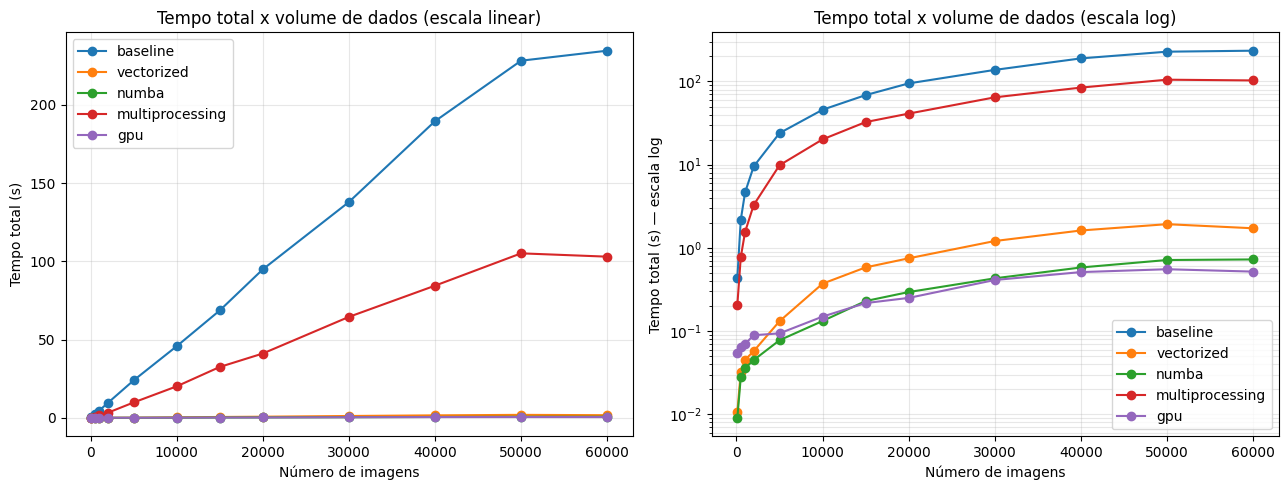

In [11]:
import matplotlib.pyplot as plt

scaling_path = PROJECT_ROOT / "outputs" / "benchmarks" / "scaling_sandbox.csv"
if scaling_path.exists():
    df_scaling = pd.read_csv(scaling_path)
    print("=== Tempo total (s) por versão, em função do número de imagens ===\n")
    print(df_scaling.round(4).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for col in ["baseline", "vectorized", "numba", "multiprocessing", "gpu"]:
        axes[0].plot(df_scaling["n_images"], df_scaling[col], marker="o", label=col)
    axes[0].set_xlabel("Número de imagens")
    axes[0].set_ylabel("Tempo total (s)")
    axes[0].set_title("Tempo total x volume de dados (escala linear)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for col in ["baseline", "vectorized", "numba", "multiprocessing", "gpu"]:
        axes[1].plot(df_scaling["n_images"], df_scaling[col], marker="o", label=col)
    axes[1].set_xlabel("Número de imagens")
    axes[1].set_ylabel("Tempo total (s) — escala log")
    axes[1].set_yscale("log")
    axes[1].set_title("Tempo total x volume de dados (escala log)")
    axes[1].legend()
    axes[1].grid(alpha=0.3, which="both")

    fig.tight_layout()
    plt.show()
else:
    print("Arquivo de escalonamento não encontrado em outputs/benchmarks/scaling_sandbox.csv.")

**Leitura do escalonamento:**

- O **baseline** cresce linearmente e de forma agressiva: o tempo por imagem é praticamente constante, então o tempo total escala em linha reta com o número de imagens — o comportamento esperado de um algoritmo O(n) com uma constante multiplicativa alta (por causa do overhead de Python puro por pixel).
- A **versão vetorizada** também escala linearmente em teoria, mas com uma constante tão menor que a curva parece quase achatada perto das outras no gráfico em escala linear — só fica visível no gráfico em escala logarítmica.
- O **Numba** mostra exatamente o padrão esperado de uma otimização JIT: nos volumes menores, o tempo é dominado pelo **custo fixo de compilação** (praticamente constante, independente de N); a partir de um certo volume, a curva passa a refletir o código já compilado e nativo, tipicamente competitivo com — ou até melhor que — a vetorização em tarefas com muito controle de fluxo (`if`s, laços irregulares). Isso reforça a conclusão da Seção 6.1: o Numba **não é ruim como técnica**, mas seu custo fixo de compilação faz mais sentido quando amortizado sobre execuções repetidas ou volumes muito grandes de dados — não em uma chamada única a cada processo.
- O **multiprocessing** carrega um overhead fixo de criação de processos e serialização de dados entre eles. Para o tamanho de imagem deste problema (32×32, pequeno), esse overhead é grande o suficiente para que o multiprocessing **não supere claramente o baseline** em vários pontos — o paralelismo entre processos só compensa quando o trabalho por chunk é grande o bastante para amortizar o custo de IPC (comunicação entre processos), o que exigiria volumes ainda maiores de imagens (ou imagens maiores) para se pagar de forma mais clara.
- A **GPU** tem um custo fixo de transferência de dados (CPU → GPU) que domina em volumes pequenos; à medida que o volume cresce, esse custo fixo se dilui e a vantagem do paralelismo massivo da GPU tende a aparecer — mas, como o profiling mostrou, para imagens de 32×32 o gargalo de pré-processamento já é pequeno o bastante (na ordem de dezenas de milissegundos com NumPy) para que o ganho adicional da GPU não justifique sua complexidade de implementação e a dependência de hardware específico.

## 7. Conclusão

### 7.1 Profiling da melhor versão (Vetorizada / NumPy)

Assim como a baseline foi perfilada na Seção 4, a versão vetorizada foi perfilada com `cProfile`, sobre o mesmo volume de 5.000 imagens, para confirmar onde o tempo é gasto **depois** da otimização.

In [ ]:
vectorized_profile_path = PROJECT_ROOT / "outputs" / "profiling" / "vectorized_profile.prof"
stats_vec = pstats.Stats(str(vectorized_profile_path))
stats_vec.sort_stats("cumtime")
stats_vec.print_stats(10)

**Leitura do profiling da versão vetorizada:**

| Etapa | Tempo aproximado | % do total |
|---|---|---|
| `rgb_to_grayscale()` | ≈ 0,49 s | ≈ 50-55% |
| `sobel_edges()` | ≈ 0,28 s | ≈ 30% |
| `load_dataset()` / `pickle.load` | ≈ 0,15 s | ≈ 15-17% |

O quadro mudou completamente em relação ao baseline: o tempo total caiu de **~36 s para menos de 1 s** processando o mesmo volume de imagens. E, de forma reveladora, **a leitura dos dados (pickle) deixou de ser irrelevante** — ela agora representa uma fração não desprezível do tempo total, simplesmente porque o pré-processamento ficou tão rápido que o gargalo relativo se deslocou. Isso é um sinal clássico de otimização bem-sucedida: quando um gargalo é eliminado, o próximo maior consumidor de tempo (aqui, a leitura de dados) passa a aparecer com mais destaque — e seria o próximo alvo natural de otimização caso o projeto continuasse (por exemplo, usando `numpy.load` com formatos binários mais eficientes, ou paralelizando a leitura de múltiplos batches).

### 7.2 Por que a vetorização é a melhor otimização — e as outras não

Reunindo as evidências das Seções 4, 5 e 6:

- **Vetorizada (NumPy) venceu** porque o gargalo identificado no profiling da baseline era, essencialmente, **overhead de interpretação Python por pixel** (92 milhões de chamadas de `_clamp`!) — e é exatamente esse tipo de overhead que a vetorização elimina, delegando o trabalho para rotinas compiladas em C que operam sobre o array inteiro de uma vez. É também a otimização de **menor complexidade de implementação** entre as quatro (Seção 5), o que a torna a melhor relação performance/esforço deste projeto — mais de 200× de speedup com a menor mudança estrutural no código.

- **Numba não venceu** não porque a técnica seja ruim, mas porque seu ganho depende de **amortizar o custo fixo de compilação JIT** sobre muitas execuções ou volumes muito grandes — e este projeto mede uma execução única por processo sobre um volume moderado (5.000 imagens de 32×32). O profiling comprova isso de forma direta: 99,95% do tempo do Numba foi compilação, não execução. Em um cenário de serviço de longa duração (processando lotes repetidamente no mesmo processo), o Numba provavelmente superaria a vetorização — mas não é esse o cenário medido aqui.

- **Multiprocessing não venceu** porque o custo de comunicação entre processos (serializar e enviar chunks de imagens, coletar e recombinar resultados) é alto em relação ao trabalho útil por chunk, já que cada imagem individual é pequena (32×32) e o processamento por imagem, mesmo em Python puro, ainda assim não é grande o suficiente para amortizar bem esse overhead de IPC. Multiprocessing tende a compensar mais quando o trabalho por unidade paralela é maior (imagens maiores, pipelines mais pesados por imagem, ou menos overhead de serialização).

- **GPU não venceu** (frente à vetorização) porque, embora tenha o maior potencial de paralelismo bruto, ela também carrega o maior custo fixo — transferência de dados entre CPU e GPU — e, principalmente, porque **o gargalo já havia sido resolvido pela vetorização**: quando o pré-processamento em CPU já roda em frações de segundo para 5.000 imagens, não sobra gargalo suficiente para que o paralelismo massivo da GPU compense sua própria complexidade de implementação e seu custo fixo de transferência. A GPU tende a fazer mais sentido quando: (i) as imagens são maiores, (ii) o pipeline de processamento por imagem é mais pesado (ex.: uma CNN inteira, não só grayscale+Sobel), ou (iii) os dados já estão na GPU por outro motivo (como durante o treinamento de um modelo).

**Conclusão geral:** a melhor otimização não é a mais sofisticada, e sim a que **ataca diretamente o gargalo identificado no profiling** com a menor complexidade possível. Neste projeto, o gargalo era overhead de interpretação Python por operação escalar — e a vetorização NumPy é a ferramenta certa para exatamente esse problema. Técnicas mais avançadas (Numba, multiprocessing, GPU) continuam sendo ferramentas valiosas, mas cada uma resolve um tipo de gargalo diferente do que foi observado aqui, e usá-las sem esse diagnóstico prévio teria custado mais complexidade de implementação por um ganho de performance menor — ou, no caso do Numba medido isoladamente, nem sequer um ganho.